# Sieci Neuronowe i algorytmy genetyczne - projekt 2026
Temat: Linear Neural Networks for Regression 

## Wprowadzenie

## Eksploracyjna analiza danych

In [1]:
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.set_printoptions(precision=3, suppress=True)

In [2]:
import tensorflow as tf
import keras
from keras import layers
from keras.layers import Normalization

In [3]:
column_names = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight", "Acceleration", "Model Year", "Origin"]

dataset = pd.read_csv("Data/auto-mpg.data",names=column_names, na_values="?", comment="\t", sep=" ", skipinitialspace="True")

In [4]:
dataset

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1


In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB


In [6]:
dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
Cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
Displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
Horsepower,392.0,104.469388,38.491160,46.0,75.000,93.5,126.000,230.0
Weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
Acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
Model Year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
Origin,398.0,1.572864,0.802055,1.0,1.000,1.0,2.000,3.0


array([[<Axes: title={'center': 'MPG'}>,
        <Axes: title={'center': 'Cylinders'}>,
        <Axes: title={'center': 'Displacement'}>],
       [<Axes: title={'center': 'Horsepower'}>,
        <Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Acceleration'}>],
       [<Axes: title={'center': 'Model Year'}>,
        <Axes: title={'center': 'Origin'}>, <Axes: >]], dtype=object)

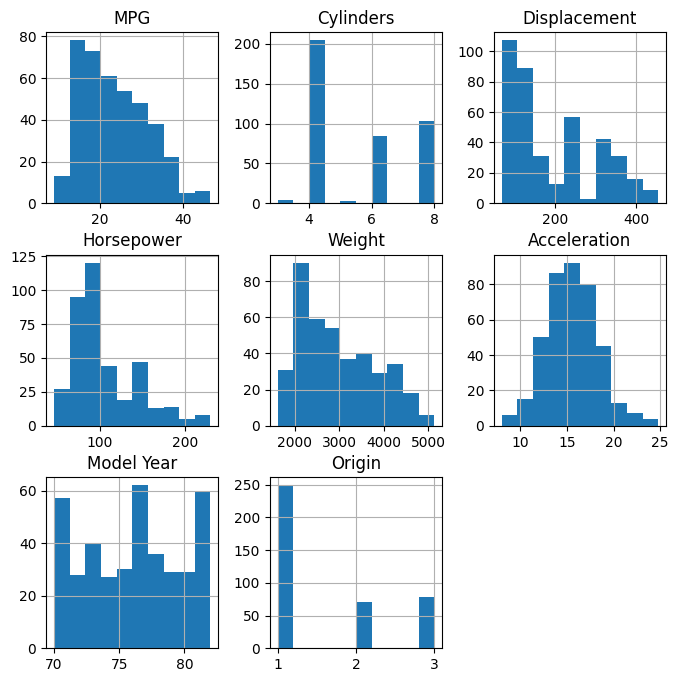

In [7]:
dataset.hist(figsize=(8,8))

<Axes: >

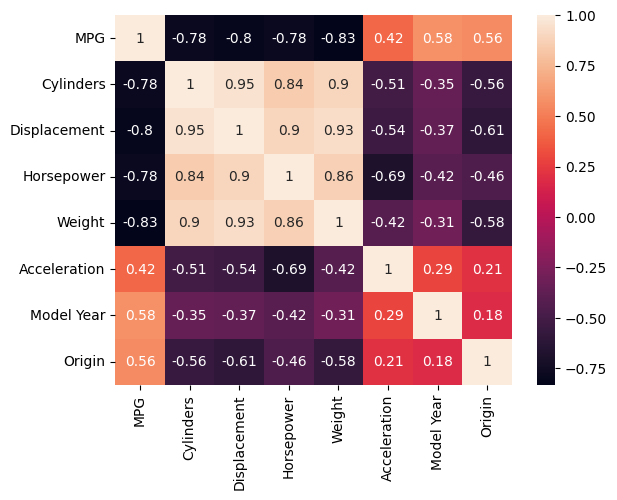

In [8]:
sns.heatmap(dataset.corr(numeric_only=True), annot=True)

## Preprocessing danych

In [9]:
dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [10]:
dataset.isna().mean() * 100

MPG             0.000000
Cylinders       0.000000
Displacement    0.000000
Horsepower      1.507538
Weight          0.000000
Acceleration    0.000000
Model Year      0.000000
Origin          0.000000
dtype: float64

In [11]:
dataset.groupby(dataset["Horsepower"].isna())["MPG"].mean()

Horsepower
False    23.445918
True     28.000000
Name: MPG, dtype: float64

Widać wyraźną zależność między średnią wartością ```MPG``` dla tych rzędów, którym brakuje wartości ```Horsepower``` oraz tymi gdzie ta wartość występuje. Mimo to ze względu na to, że ilość takich rzędów jest marginalna można je po prostu usunąć zamiast wypełniać uśrednionymi wartościami. 

In [12]:
# clear dataset
dataset_cleared = dataset.dropna()

# convert categorical "Origin" data into one-hot data
dataset_cleared = pd.get_dummies(dataset_cleared, columns=["Origin"], prefix="Origin", dtype=int)
dataset_cleared = dataset_cleared.rename(columns={"Origin_1": "USA", "Origin_2": "Europe", "Origin_3": "Japan"})

In [13]:
dataset_cleared

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,USA,Europe,Japan
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,0,0
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,0,0
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,0,0
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,0,0
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,0,0
...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,0,0
394,44.0,4,97.0,52.0,2130.0,24.6,82,0,1,0
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,0,0
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,0,0


In [14]:
dataset_cleared.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,392.0,23.445918,7.805007,9.0,17.000,22.75,29.000,46.6
Cylinders,392.0,5.471939,1.705783,3.0,4.000,4.00,8.000,8.0
Displacement,392.0,194.411990,104.644004,68.0,105.000,151.00,275.750,455.0
Horsepower,392.0,104.469388,38.491160,46.0,75.000,93.50,126.000,230.0
Weight,392.0,2977.584184,849.402560,1613.0,2225.250,2803.50,3614.750,5140.0
Acceleration,392.0,15.541327,2.758864,8.0,13.775,15.50,17.025,24.8
Model Year,392.0,75.979592,3.683737,70.0,73.000,76.00,79.000,82.0
USA,392.0,0.625000,0.484742,0.0,0.000,1.00,1.000,1.0
Europe,392.0,0.173469,0.379136,0.0,0.000,0.00,0.000,1.0
Japan,392.0,0.201531,0.401656,0.0,0.000,0.00,0.000,1.0


array([[<Axes: title={'center': 'MPG'}>,
        <Axes: title={'center': 'Cylinders'}>,
        <Axes: title={'center': 'Displacement'}>],
       [<Axes: title={'center': 'Horsepower'}>,
        <Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Acceleration'}>],
       [<Axes: title={'center': 'Model Year'}>,
        <Axes: title={'center': 'USA'}>,
        <Axes: title={'center': 'Europe'}>],
       [<Axes: title={'center': 'Japan'}>, <Axes: >, <Axes: >]],
      dtype=object)

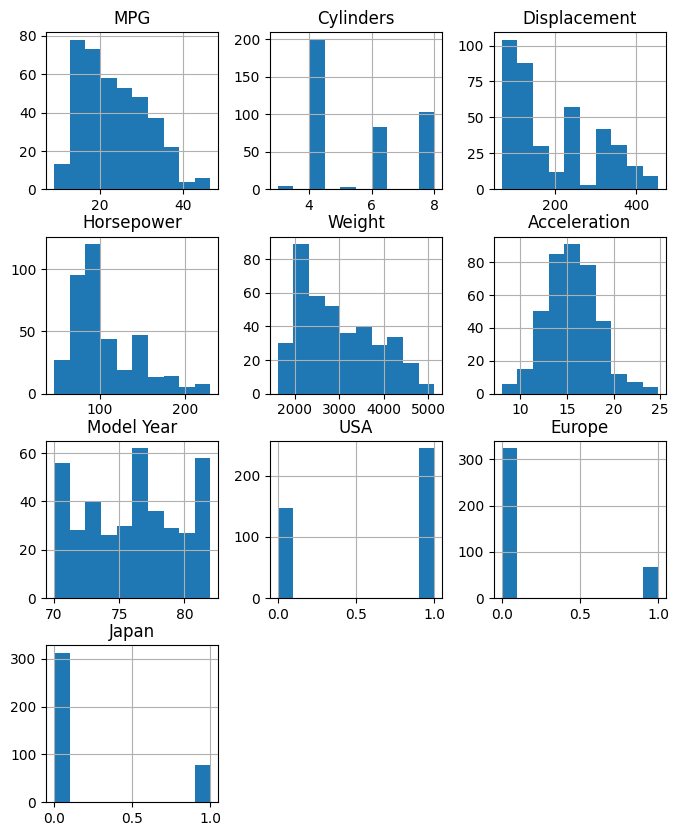

In [15]:
dataset_cleared.hist(figsize=(8,10))

<Axes: >

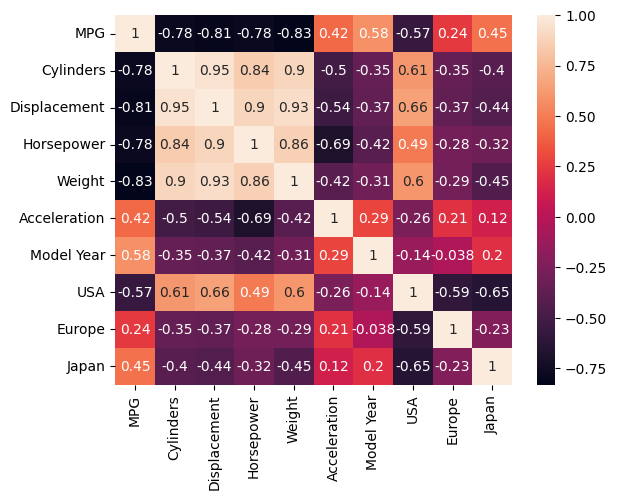

In [16]:
sns.heatmap(dataset_cleared.corr(numeric_only=True), annot=True)

In [17]:
dataset_cleared["Horsepower"] = np.log1p(dataset_cleared["Horsepower"])
dataset_cleared["Displacement"] = np.log1p(dataset_cleared["Displacement"])
dataset_cleared["Weight"] = np.log1p(dataset_cleared["Weight"])

array([[<Axes: title={'center': 'MPG'}>,
        <Axes: title={'center': 'Cylinders'}>,
        <Axes: title={'center': 'Displacement'}>],
       [<Axes: title={'center': 'Horsepower'}>,
        <Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Acceleration'}>],
       [<Axes: title={'center': 'Model Year'}>,
        <Axes: title={'center': 'USA'}>,
        <Axes: title={'center': 'Europe'}>],
       [<Axes: title={'center': 'Japan'}>, <Axes: >, <Axes: >]],
      dtype=object)

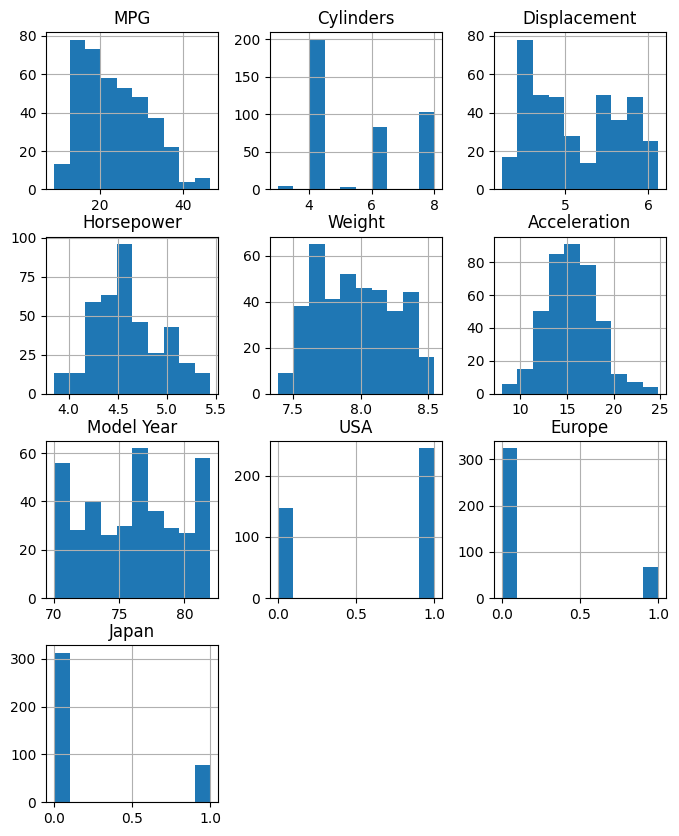

In [18]:
dataset_cleared.hist(figsize=(8,10))

<Axes: >

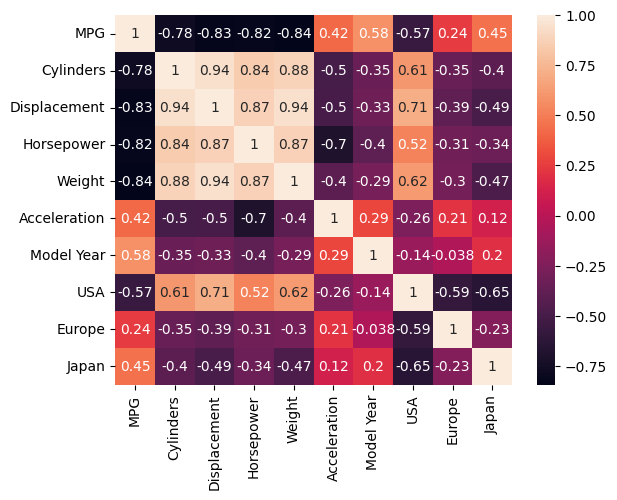

In [19]:
sns.heatmap(dataset_cleared.corr(numeric_only=True), annot=True)

<Axes: xlabel='Horsepower', ylabel='MPG'>

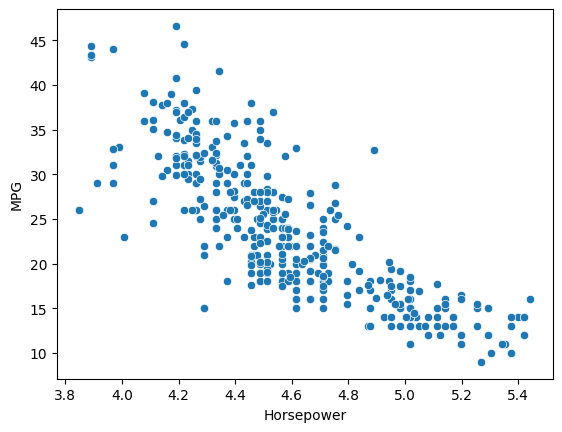

In [20]:
sns.scatterplot(x="Horsepower", y="MPG", data=dataset_cleared)

<Axes: xlabel='Weight', ylabel='MPG'>

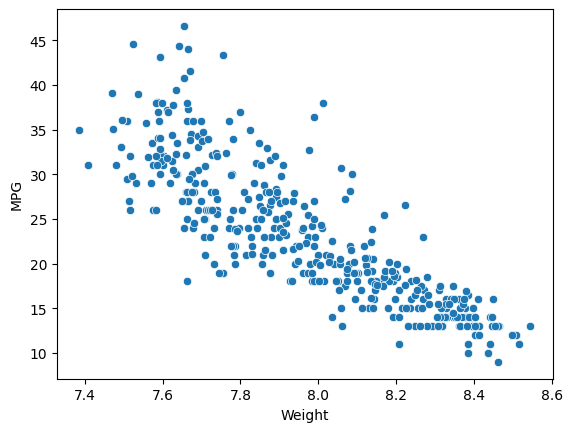

In [21]:
sns.scatterplot(x="Weight", y="MPG", data=dataset_cleared)

## Podział danych na treningowe oraz testowe

In [22]:
from sklearn.model_selection import train_test_split

X = dataset_cleared.drop(["MPG"], axis=1)
Y = dataset_cleared["MPG"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

train_dataset = X_train.join(Y_train)

In [23]:
# Normalization for multi-feature model
normalizer = Normalization()

# Adapt to data
normalizer.adapt(np.array(X_train))

print(train_dataset.describe().transpose()[["mean", "std"]])
print(normalizer.mean.numpy())

                   mean       std
Cylinders      5.482428  1.700446
Displacement   5.142527  0.527146
Horsepower     4.600056  0.340087
Weight         7.963020  0.279766
Acceleration  15.544089  2.817864
Model Year    76.207668  3.630136
USA            0.645367  0.479168
Europe         0.153355  0.360906
Japan          0.201278  0.401597
MPG           23.599361  7.956255
[[ 5.482  5.143  4.6    7.963 15.544 76.208  0.645  0.153  0.201]]


In [24]:
first_row = np.array(X_train[:1])

print("First row of training features:", first_row)
print("Normalized:", normalizer(first_row).numpy())

First row of training features: [[ 6.     5.421  4.71   8.195 18.7   78.     1.     0.     0.   ]]
Normalized: [[ 0.305  0.528  0.322  0.829  1.122  0.495  0.741 -0.426 -0.502]]


In [25]:
# Implementation of normalizer for single feature
feature = "Horsepower"
single_feature = np.array(X_train[feature]).reshape(-1,1)

print(single_feature.shape, X_train.shape)

single_feature_normalizer = Normalization()

single_feature_normalizer.adapt(single_feature)

(313, 1) (313, 9)


## Budowa i trening modeli oraz ich ewaluacja

In [26]:
def build_model(normalizer, lr):
    model = keras.models.Sequential([
        normalizer,
        keras.layers.Dense(units=1)
    ])
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=lr),
        loss = keras.losses.MeanAbsoluteError()
    )
    return model

In [27]:
def plot_loss(history, title):
    plt.plot(history.history["loss"], label="loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.ylim([0, 25])
    plt.xlabel("Epoch")
    plt.ylabel("Error [MPG]")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [28]:
def plot(feature, x=None, y=None):
    plt.figure(figsize=(10,10))
    plt.scatter(X_train[feature], Y_train, label="Data")
    if x is not None and y is not None:
        plt.plot(x, y, color="k", label="Predictions")
    plt.xlabel(feature)
    plt.ylabel("MPG")
    plt.legend
    plt.show()

### Single feature models

In [29]:
all_results = []

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (313, 1)               │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (16.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3 (16.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 22.8378 - val_loss: 24.5200
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 22.0244 - val_loss: 23.7373
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 21.2128 - val_loss: 22.9864
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.4003 - val_loss: 22.2315
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 19.6108 - val_loss: 21.5027
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18.7789 - val_loss: 20.7281
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 17.9933 - val_loss: 19.9430
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.2243 - val_loss: 19.1540
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 16.4692 - val_loss: 18.3697
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15.7351 - val_loss: 17.5859
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.9900 - val_loss: 16.8211
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.2485 - val_lo

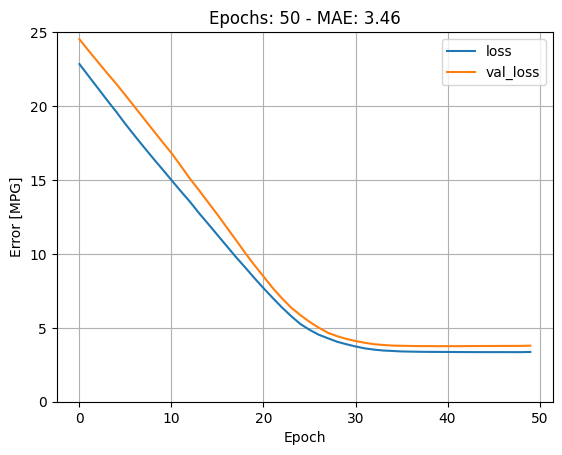

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


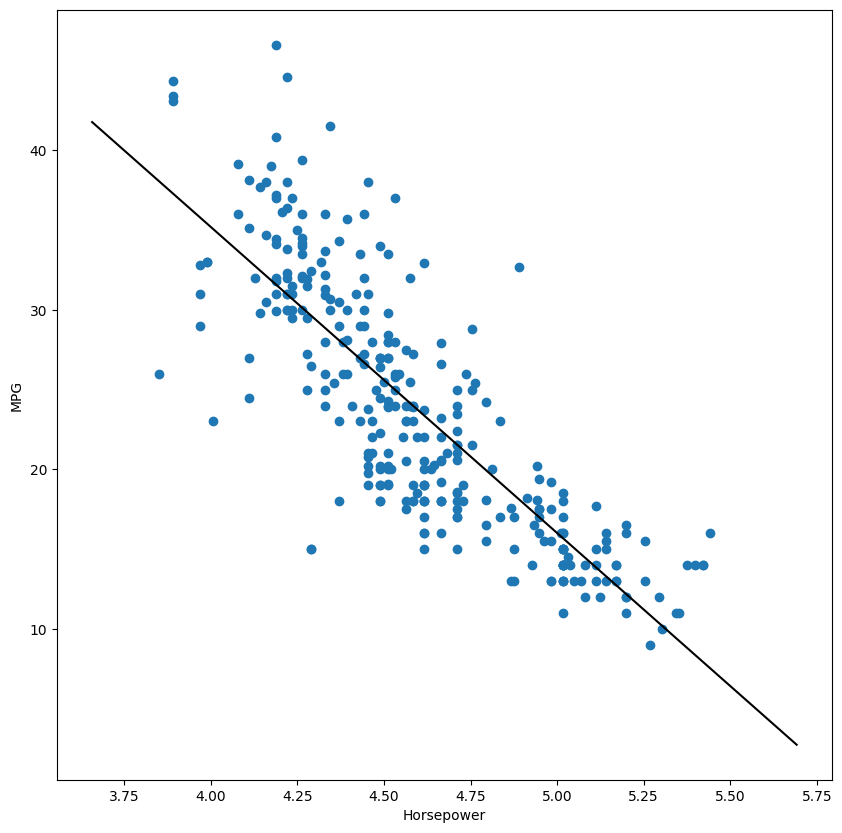

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (16.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3 (16.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 22.9650 - val_loss: 23.9858
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 22.1542 - val_loss: 23.2234
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 21.3534 - val_loss: 22.4826
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.5366 - val_loss: 21.7288
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 19.7282 - val_loss: 20.9746
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 18.9103 - val_loss: 20.1888
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18.1030 - val_loss: 19.4203
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.2938 - val_loss: 18.6578
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 16.4860 - val_loss: 17.9079
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 15.6724 - val_loss: 17.1445
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.8701 - val_loss: 16.3791
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14.0

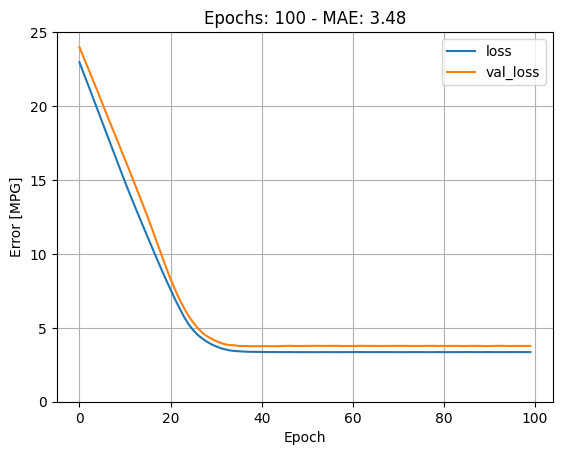

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


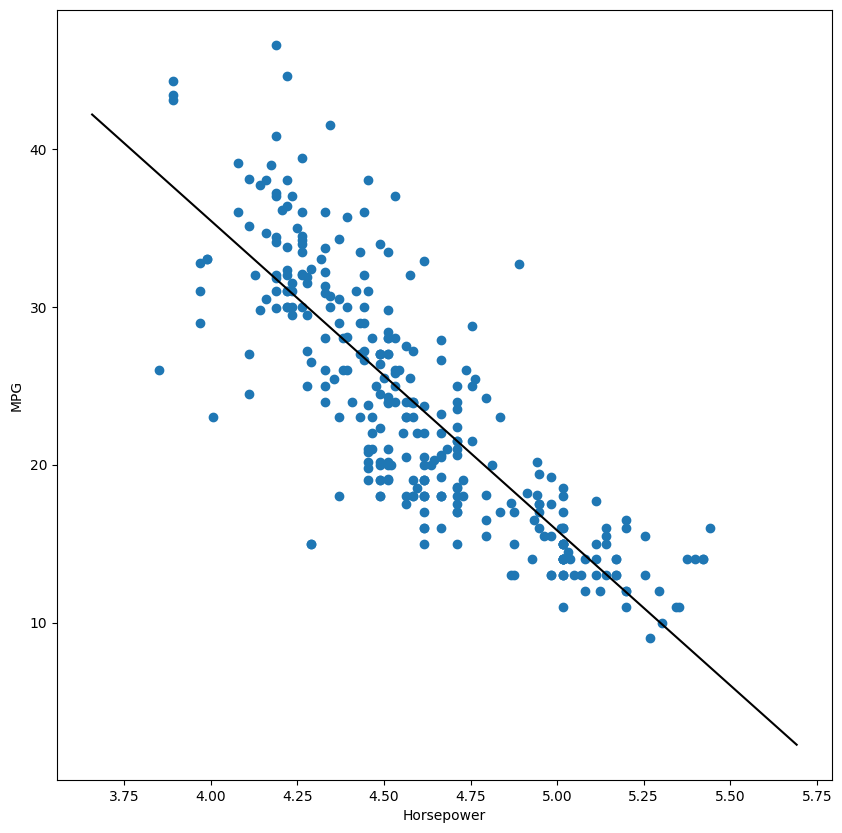

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (16.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3 (16.00 B)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 22.9078 - val_loss: 24.2487
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.0901 - val_loss: 23.4726
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 21.2926 - val_loss: 22.7291
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.4701 - val_loss: 21.9613
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.6628 - val_loss: 21.1873
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 18.8529 - val_loss: 20.4214
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 18.0495 - val_loss: 19.6728
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 17.2405 - val_loss: 18.9194
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 16.4321 - val_loss: 18.1463
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15.6570 - val_loss: 17.3718
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.8917 - val_loss: 16.5740
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.1

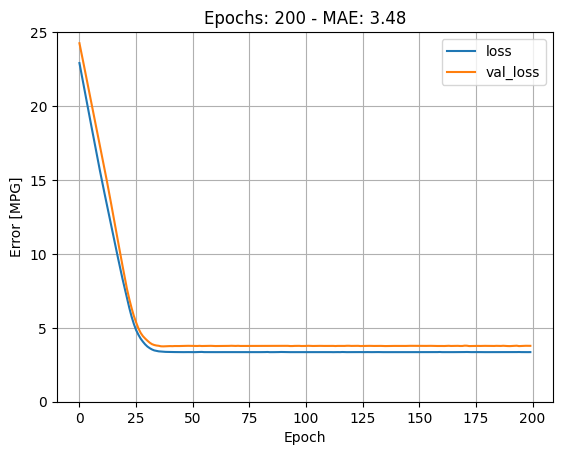

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


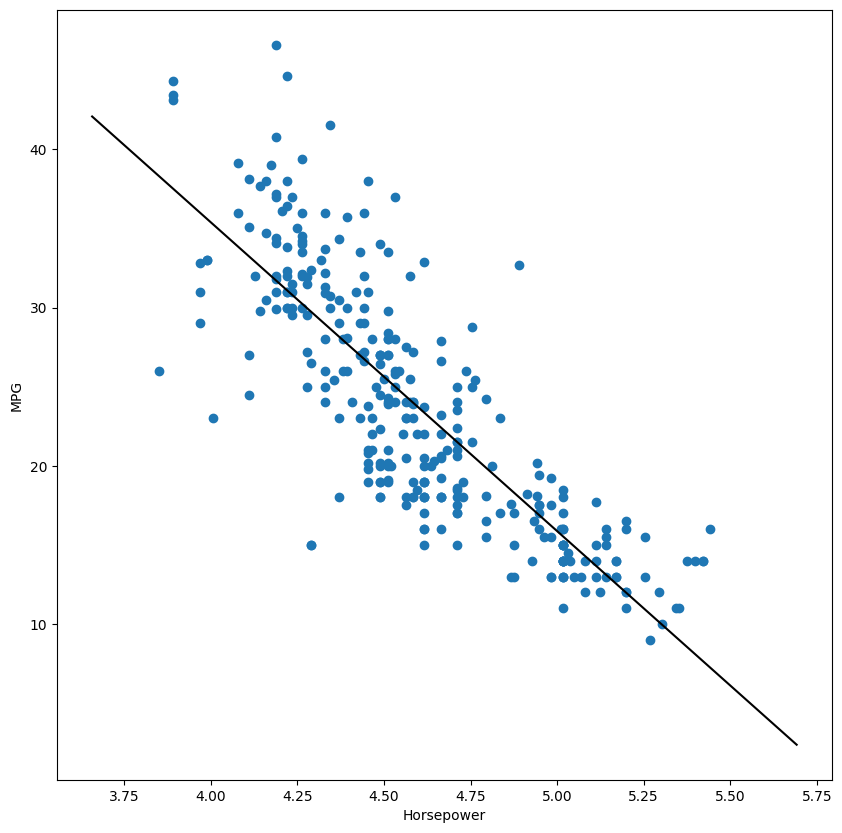

{50: 3.461380958557129, 100: 3.4813625812530518, 200: 3.4753386974334717}


In [30]:
results = {}

for epochs in [50, 100, 200]:
    single_feature_model = build_model(single_feature_normalizer, lr=0.1)
    single_feature_model.summary()
    history = single_feature_model.fit(
        X_train[[feature]], Y_train,
        epochs=epochs,
        verbose=1,
        validation_split=0.2
    )
    mae = single_feature_model.evaluate(X_test[[feature]], Y_test, verbose=1)
    results[epochs] = mae
    plot_loss(history, title=f"Epochs: {epochs} - MAE: {mae:.2f}")
    
    # predict and plot predictions
    range_min = np.min(X_test[feature]) * 0.95
    range_max = np.max(X_test[feature]) * 1.05
    x = tf.linspace(range_min, range_max, 200)
    y = single_feature_model.predict(x)

    plot(feature, x,y)

print(results)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (16.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3 (16.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 23.2882 - val_loss: 24.6253
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 23.2063 - val_loss: 24.5499
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 23.1247 - val_loss: 24.4737
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 23.0451 - val_loss: 24.4007
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22.9622 - val_loss: 24.3231
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22.8814 - val_loss: 24.2475
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22.8005 - val_loss: 24.1725
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.7203 - val_loss: 24.0990
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 22.6376 - val_loss: 24.0217
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.5581 - val_loss: 23.9482
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22.4764 - val_loss: 23.8731
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22.3

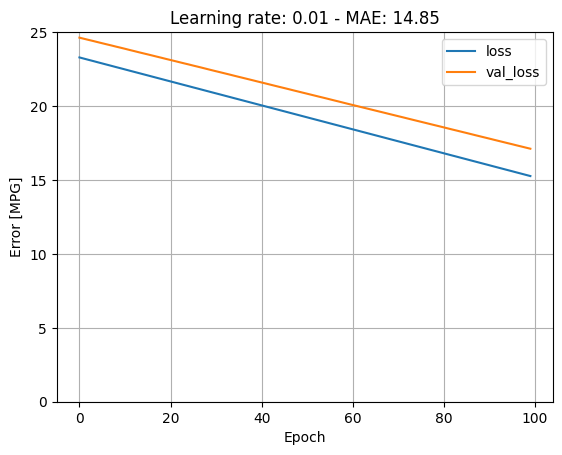

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


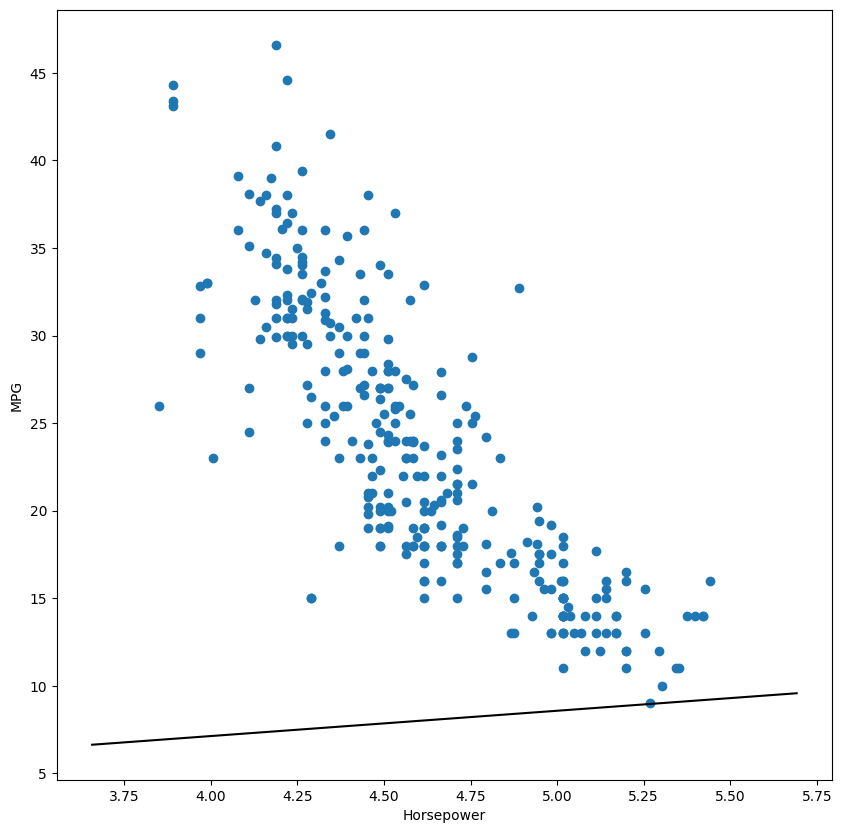

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (16.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3 (16.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 22.9097 - val_loss: 24.2103
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.0980 - val_loss: 23.4477
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 21.2871 - val_loss: 22.6827
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.4766 - val_loss: 21.9231
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.6691 - val_loss: 21.1794
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18.8543 - val_loss: 20.4198
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18.0442 - val_loss: 19.6706
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 17.2300 - val_loss: 18.8991
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 16.4350 - val_loss: 18.1657
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15.6549 - val_loss: 17.3938
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14.9029 - val_loss: 16.5992
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 14.1

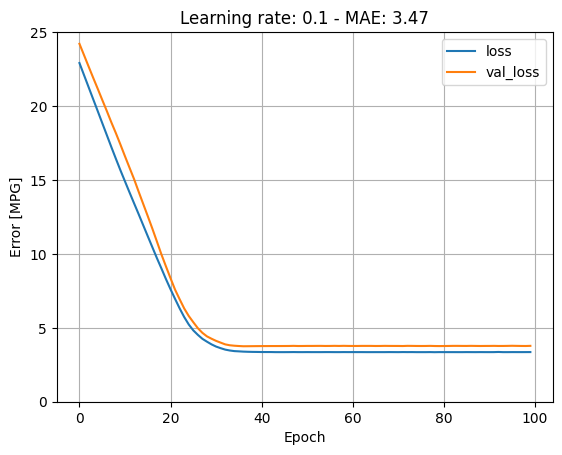

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


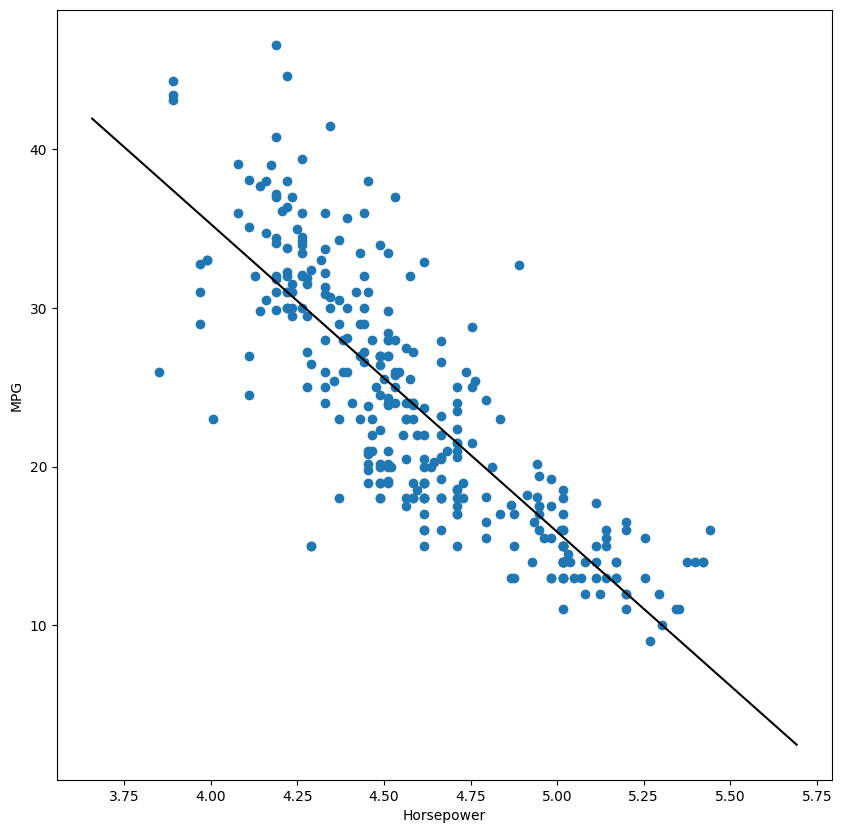

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (16.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3 (16.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 19.8016 - val_loss: 17.3870
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12.1705 - val_loss: 9.3484
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.4761 - val_loss: 3.7679
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.7947 - val_loss: 4.4888
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.1591 - val_loss: 4.1965
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.5193 - val_loss: 3.7732
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4828 - val_loss: 3.9404
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3978 - val_loss: 3.7678
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.5305 - val_loss: 3.8799
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4274 - val_loss: 3.8347
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4769 - val_loss: 3.7359
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3729 - val_loss: 3.98

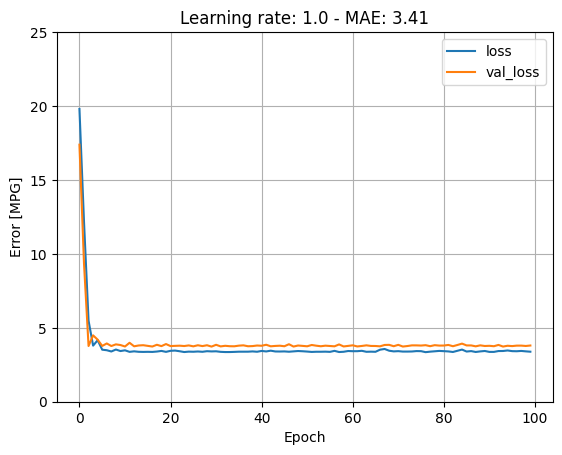

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


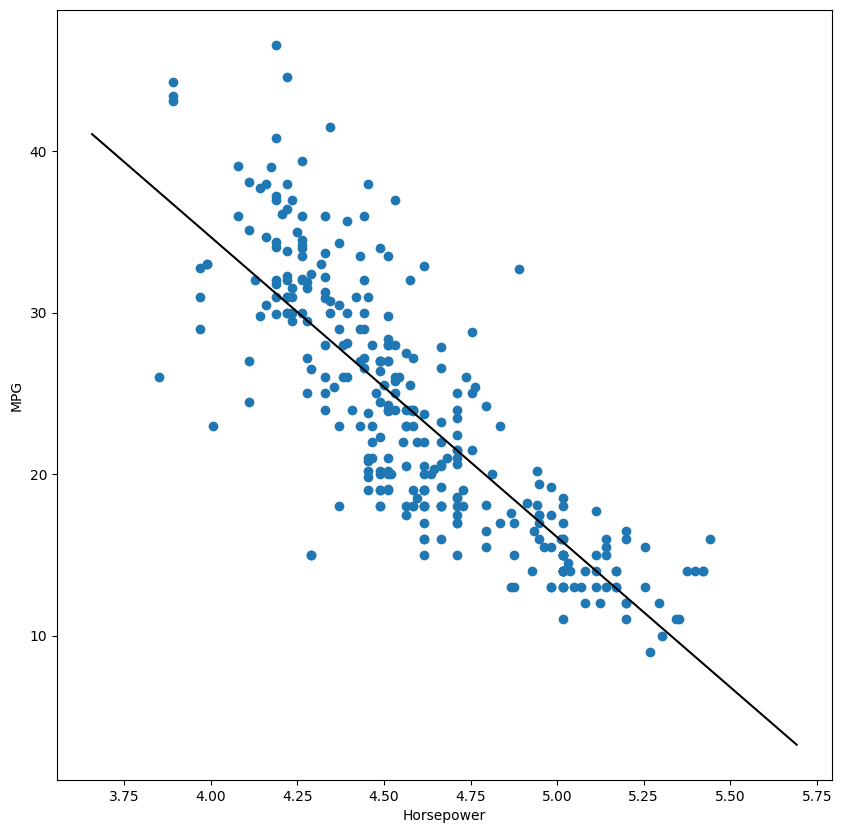

{0.01: 14.84831428527832, 0.1: 3.465364456176758, 1.0: 3.405003786087036}


In [31]:
results = {}

for learning_rate in [0.01, 0.1, 1.0]:
    single_feature_model = build_model(single_feature_normalizer, lr=learning_rate)
    single_feature_model.summary()
    history = single_feature_model.fit(
        X_train[[feature]], Y_train,
        epochs=100,
        verbose=1,
        validation_split=0.2
    )
    mae = single_feature_model.evaluate(X_test[feature], Y_test, verbose=1)
    results[learning_rate] = mae
    plot_loss(history, title=f"Learning rate: {learning_rate} - MAE: {mae:.2f}")
    
    # plot predictions
    range_min = np.min(X_test[feature]) * 0.95
    range_max = np.max(X_test[feature]) * 1.05
    x = tf.linspace(range_min, range_max, 200)
    y = single_feature_model.predict(x)

    plot(feature, x,y)

print(results)

### Multi feature linear model

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (313, 9)               │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 22.9014 - val_loss: 24.6103
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 21.9955 - val_loss: 24.0034
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 21.1378 - val_loss: 23.3776
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 20.3185 - val_loss: 22.8401
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19.5383 - val_loss: 22.0940
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18.6978 - val_loss: 21.2145
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.9473 - val_loss: 20.3531
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17.1508 - val_loss: 19.5909
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 16.3599 - val_loss: 18.8815
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15.5718 - val_loss: 18.1421
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.7940 - val_loss: 17.2253
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.0163 - val_lo

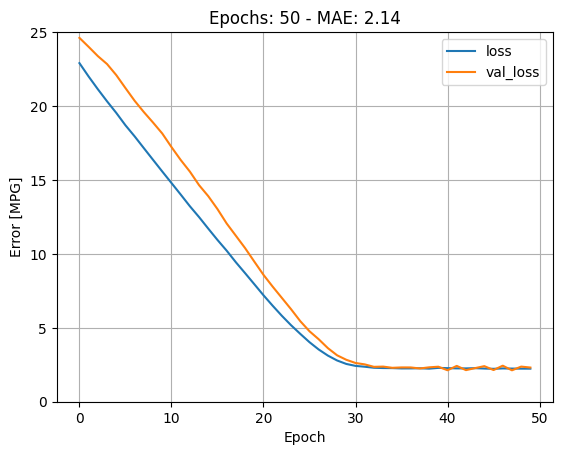

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


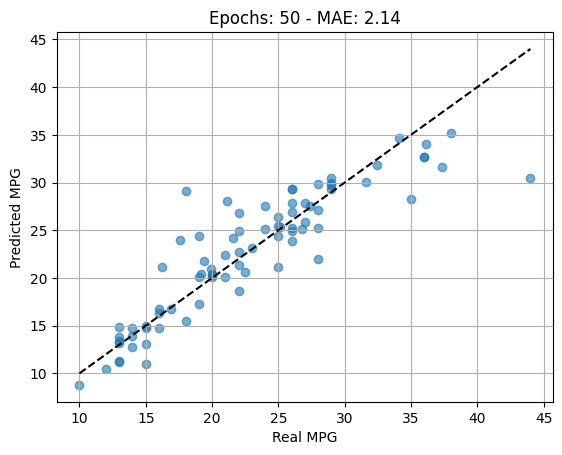

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 22.9235 - val_loss: 24.4079
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.0356 - val_loss: 23.7872
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 21.1946 - val_loss: 23.2252
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 20.3344 - val_loss: 22.6683
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.5029 - val_loss: 22.0503
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18.7068 - val_loss: 21.3542
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.9264 - val_loss: 20.4966
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.1427 - val_loss: 19.5764
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 16.3747 - val_loss: 18.8162
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 15.5736 - val_loss: 18.0480
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.8043 - val_loss: 17.2976
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.

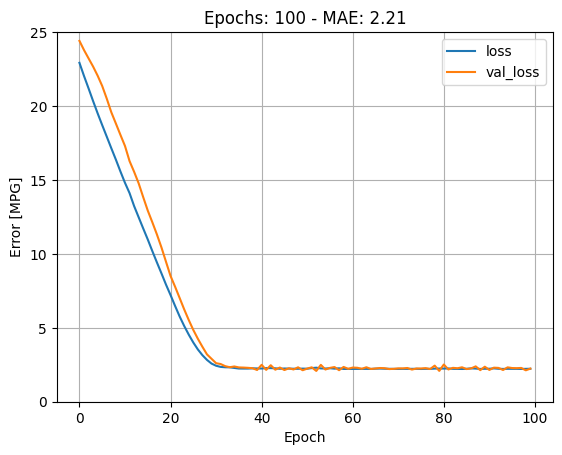

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


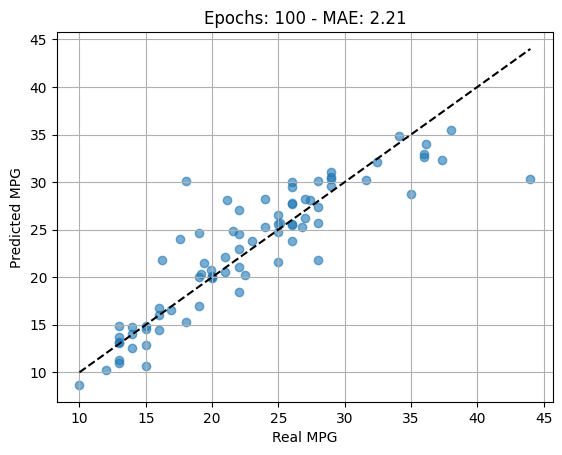

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 22.9430 - val_loss: 24.4411
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22.0397 - val_loss: 23.8484
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 21.1767 - val_loss: 23.2182
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.3421 - val_loss: 22.6758
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.4741 - val_loss: 22.0802
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18.6597 - val_loss: 21.4504
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.9049 - val_loss: 20.7287
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.0938 - val_loss: 19.7946
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 16.3279 - val_loss: 18.9027
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15.5372 - val_loss: 18.1506
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.7555 - val_loss: 17.3136
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 13.

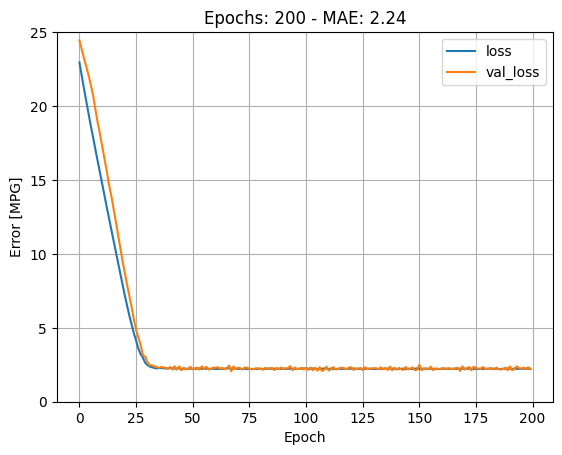

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


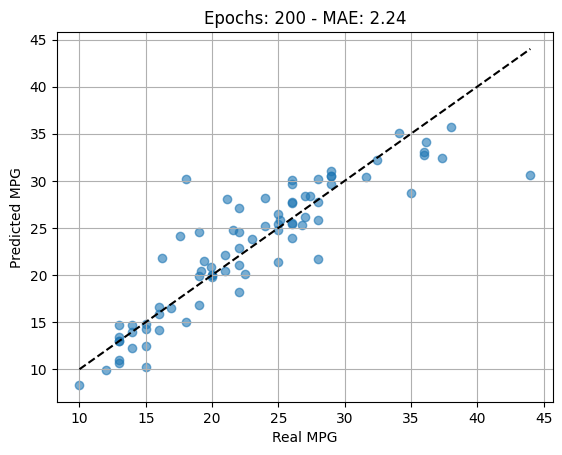

{50: 2.1380317211151123, 100: 2.2082667350769043, 200: 2.2441022396087646}


In [32]:
results = {}

for epochs in [50, 100, 200]:
    linear_model = build_model(normalizer, lr=0.1)
    linear_model.summary()
    history = linear_model.fit(
        X_train, Y_train,
        epochs=epochs,
        verbose=1,
        validation_split=0.2
    )
    mae = linear_model.evaluate(X_test, Y_test, verbose=1)
    results[epochs] = mae
    plot_loss(history, title=f"Epochs: {epochs} - MAE: {mae:.2f}")
    
    y_pred = linear_model.predict(X_test).flatten()
    plt.figure()
    plt.scatter(Y_test, y_pred, alpha=0.6)
    plt.plot([Y_test.min(), Y_test.max()],
             [Y_test.min(), Y_test.max()], color="k", linestyle="--")
    plt.xlabel("Real MPG")
    plt.ylabel("Predicted MPG")
    plt.title(f"Epochs: {epochs} - MAE: {mae:.2f}")
    plt.grid(True)
    plt.show()

print(results)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 23.1946 - val_loss: 25.0376
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 23.1024 - val_loss: 24.9804
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 23.0168 - val_loss: 24.9140
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22.9343 - val_loss: 24.8562
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22.8486 - val_loss: 24.7925
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.7628 - val_loss: 24.7290
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.6784 - val_loss: 24.6681
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.5941 - val_loss: 24.6052
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.5115 - val_loss: 24.5476
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.4265 - val_loss: 24.4886
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22.3415 - val_loss: 24.4285
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.2

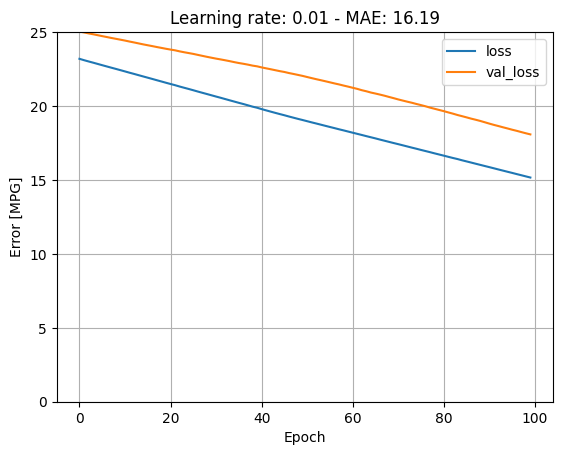

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


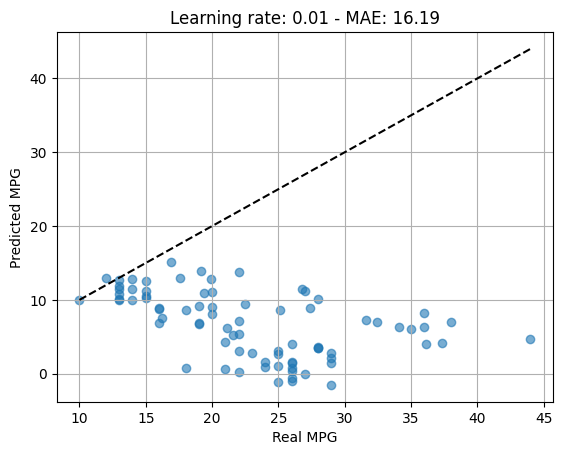

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 22.8965 - val_loss: 24.8170
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 21.9476 - val_loss: 24.1185
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 21.1629 - val_loss: 23.6592
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 20.2575 - val_loss: 22.9548
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.4851 - val_loss: 22.1099
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18.6891 - val_loss: 21.3476
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.9008 - val_loss: 20.5690
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.1224 - val_loss: 19.7250
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 16.3461 - val_loss: 18.9666
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15.5717 - val_loss: 18.0421
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.7998 - val_loss: 17.4036
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13.9

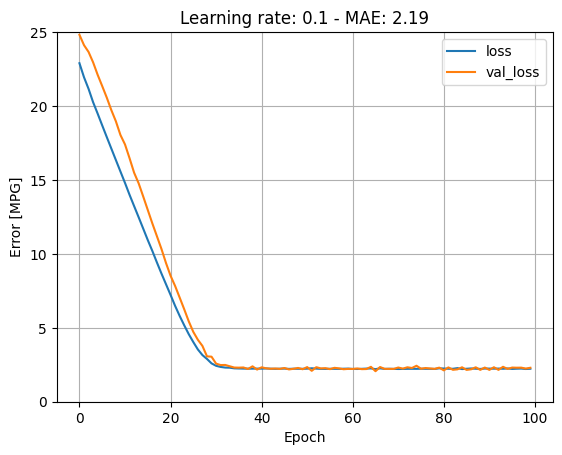

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


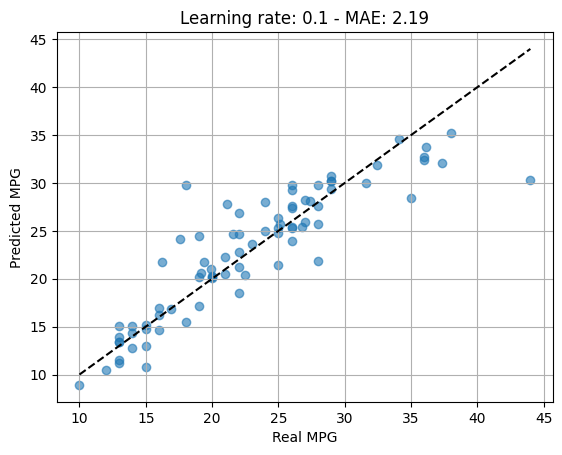

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 20.0782 - val_loss: 18.0621
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11.7997 - val_loss: 9.0697
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.3369 - val_loss: 4.0308
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3560 - val_loss: 3.4470
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3014 - val_loss: 2.8633
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5047 - val_loss: 2.4556
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5774 - val_loss: 2.1217
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5170 - val_loss: 2.0499
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4765 - val_loss: 2.1070
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4371 - val_loss: 2.2207
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4334 - val_loss: 2.1888
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3307 - val_loss: 2.25

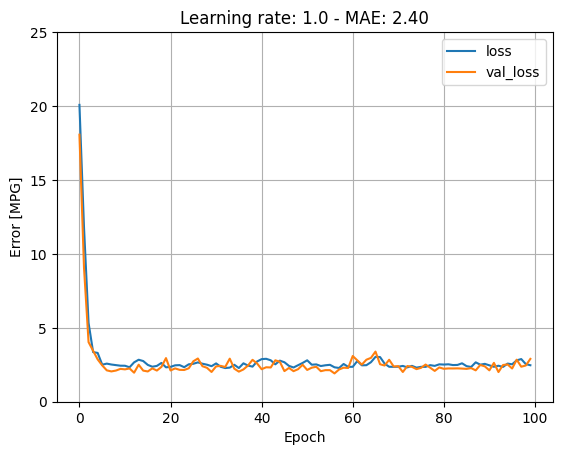

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


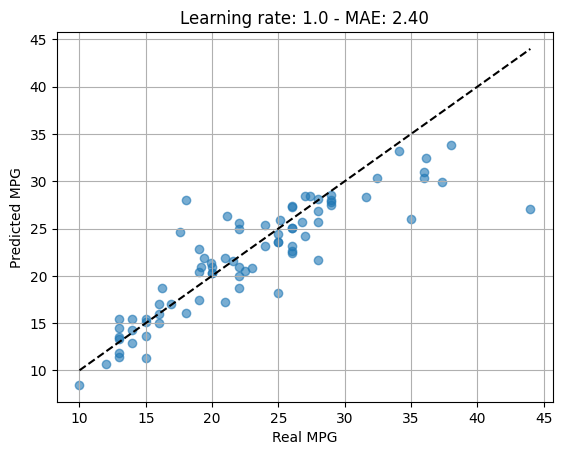

{0.01: 16.19443130493164, 0.1: 2.1918256282806396, 1.0: 2.40002179145813}


In [33]:
results = {}

for learning_rate in [0.01, 0.1, 1.0]: 
    linear_model = build_model(normalizer, lr=learning_rate)
    linear_model.summary()
    history = linear_model.fit(
        X_train, Y_train,
        epochs=100,
        verbose=1,
        validation_split=0.2
    )
    mae = linear_model.evaluate(X_test, Y_test, verbose=1)
    results[learning_rate] = mae
    plot_loss(history, title=f"Learning rate: {learning_rate} - MAE: {mae:.2f}")
    
    y_pred = linear_model.predict(X_test).flatten()
    plt.figure()
    plt.scatter(Y_test, y_pred, alpha=0.6)
    plt.plot([Y_test.min(), Y_test.max()],
             [Y_test.min(), Y_test.max()], color="k", linestyle="--")
    plt.xlabel("Real MPG")
    plt.ylabel("Predicted MPG")
    plt.title(f"Learning rate: {learning_rate} - MAE: {mae:.2f}")
    plt.grid(True)
    plt.show()

print(results)

## Eksperyment z siecią nieliniową

In [34]:
def build_deep_model(normalizer, lr):
    model = keras.models.Sequential([
        normalizer,
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.MeanAbsoluteError()
    )
    return model

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 11.3350 - val_loss: 5.0375
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.9234 - val_loss: 3.3158
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.0659 - val_loss: 5.9846
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0127 - val_loss: 3.5698
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.6621 - val_loss: 2.7085
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.1048 - val_loss: 2.6813
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.4416 - val_loss: 2.3072
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9033 - val_loss: 2.5396
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.6482 - val_loss: 1.9315
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.0834 - val_loss: 1.9438
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3456 - val_loss: 3.4552
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.9732 - val_loss: 4.5525
Epoch 13/5

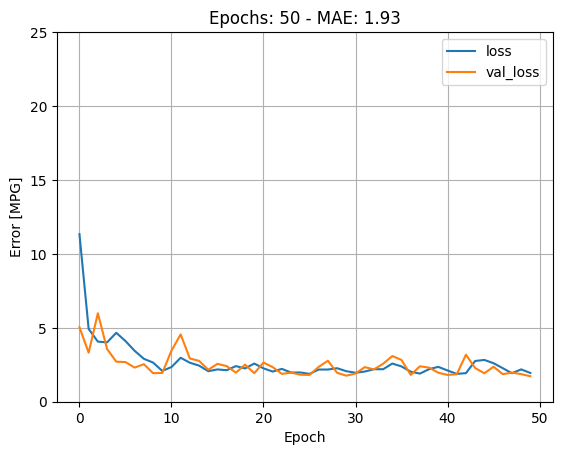

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


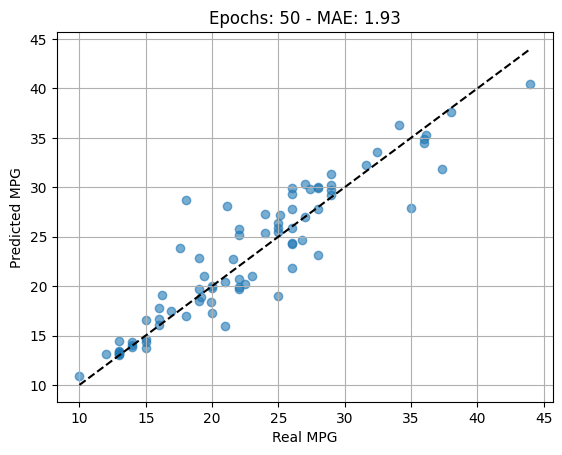

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 12.8586 - val_loss: 13.2958
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.5316 - val_loss: 4.0240
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.4081 - val_loss: 4.0616
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.9348 - val_loss: 3.6831
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.5661 - val_loss: 2.9877
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.8773 - val_loss: 2.5619
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.4588 - val_loss: 2.0483
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.6000 - val_loss: 1.9510
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2844 - val_loss: 2.0601
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.5620 - val_loss: 4.1741
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.7588 - val_loss: 3.1985
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.3721 - val_loss: 2.26

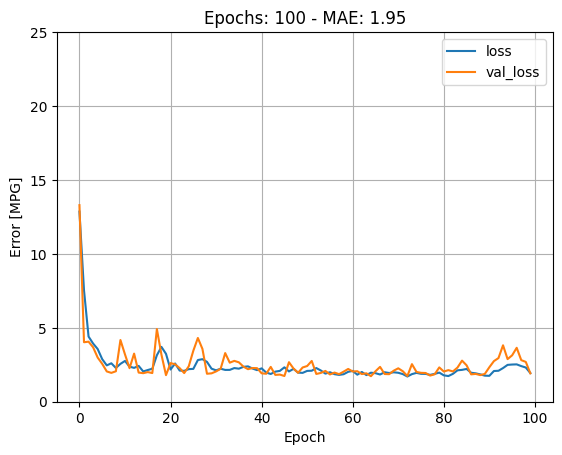

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


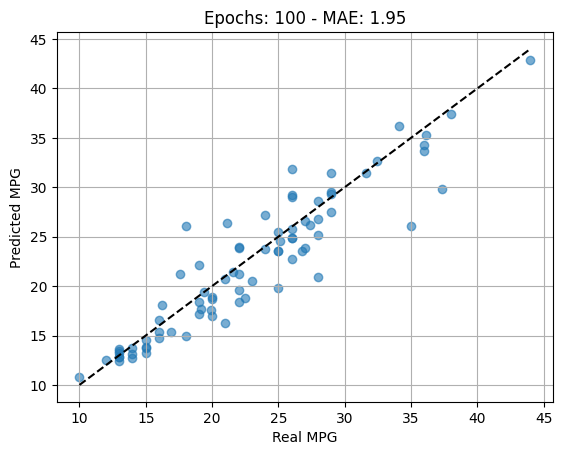

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 13.0175 - val_loss: 8.2459
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.9550 - val_loss: 5.1317
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.6436 - val_loss: 2.5085
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8700 - val_loss: 3.8861
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5223 - val_loss: 4.2649
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.1332 - val_loss: 2.2190
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.5040 - val_loss: 2.7304
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.6859 - val_loss: 2.0810
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8534 - val_loss: 3.1205
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.3420 - val_loss: 2.7217
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2995 - val_loss: 2.2822
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.3076 - val_loss: 2.2047

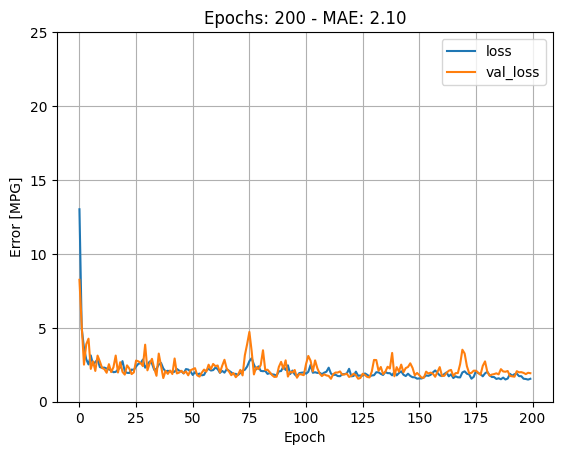

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


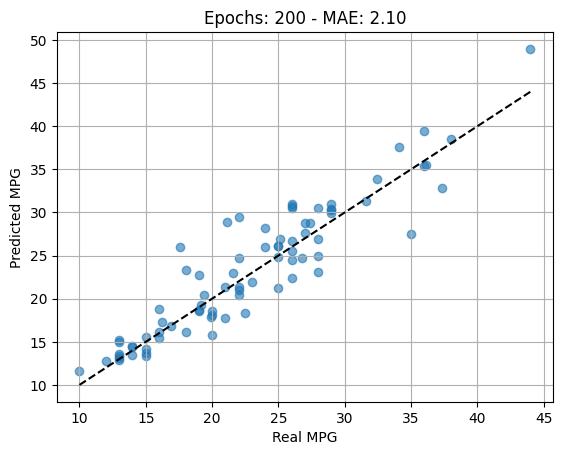

{50: 1.9315913915634155, 100: 1.9466661214828491, 200: 2.0972936153411865}


In [35]:
results = {}

for epochs in [50, 100, 200]:
    dnn_model = build_deep_model(normalizer, lr=0.1)
    dnn_model.summary()
    history = dnn_model.fit(
        X_train, Y_train,
        epochs=epochs,
        verbose=1,
        validation_split=0.2
    )
    mae = dnn_model.evaluate(X_test, Y_test, verbose=1)
    results[epochs] = mae
    plot_loss(history, title=f"Epochs: {epochs} - MAE: {mae:.2f}")
    
    y_pred = dnn_model.predict(X_test).flatten()
    plt.figure()
    plt.scatter(Y_test, y_pred, alpha=0.6)
    plt.plot([Y_test.min(), Y_test.max()],
             [Y_test.min(), Y_test.max()], color="k", linestyle="--")
    plt.xlabel("Real MPG")
    plt.ylabel("Predicted MPG")
    plt.title(f"Epochs: {epochs} - MAE: {mae:.2f}")
    plt.grid(True)
    plt.show()

print(results)

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 19.8354 - val_loss: 14.5212
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.9132 - val_loss: 8.3527
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.0995 - val_loss: 5.4031
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2615 - val_loss: 3.1342
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1422 - val_loss: 2.5536
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9061 - val_loss: 2.1004
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5767 - val_loss: 2.5703
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4175 - val_loss: 2.6920
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4345 - val_loss: 2.0412
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1660 - val_loss: 2.1031
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1130 - val_loss: 2.0624
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1744 - val_loss: 2.259

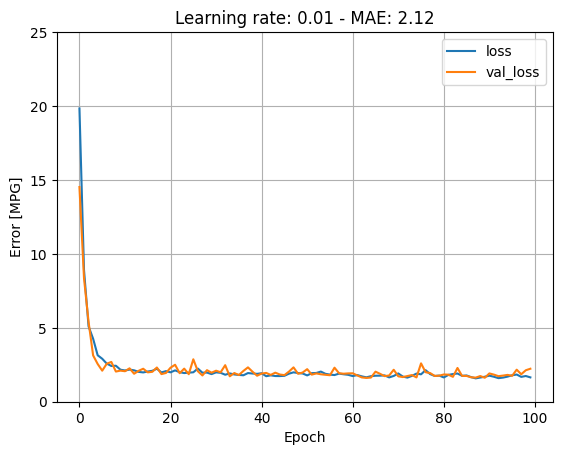

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


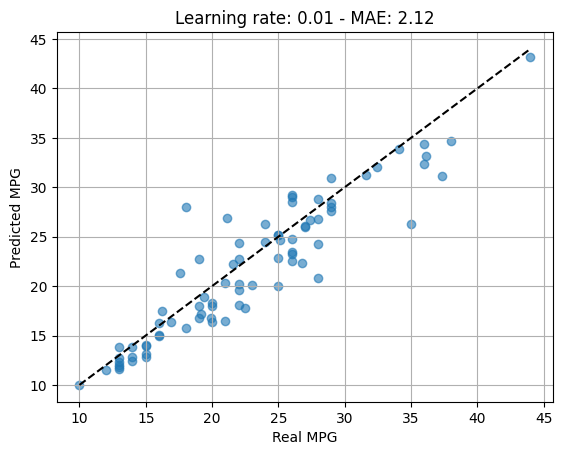

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 14.9666 - val_loss: 12.3443
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.3993 - val_loss: 3.7373
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.1634 - val_loss: 3.2582
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3851 - val_loss: 2.6266
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4427 - val_loss: 2.6570
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4478 - val_loss: 3.1218
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.9936 - val_loss: 2.1038
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.5734 - val_loss: 2.1737
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7158 - val_loss: 2.2904
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1812 - val_loss: 2.3598
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0126 - val_loss: 2.1543
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5577 - val_loss: 2.017

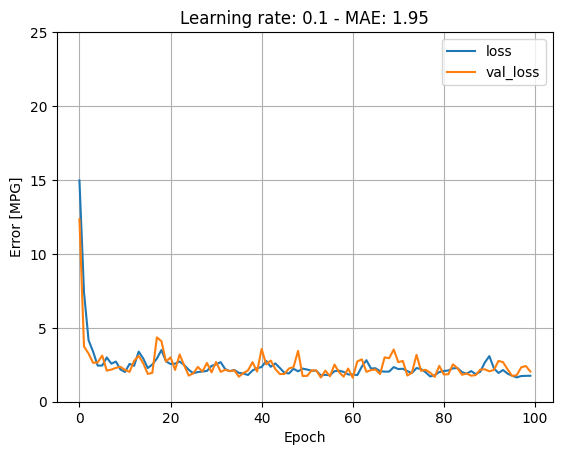

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


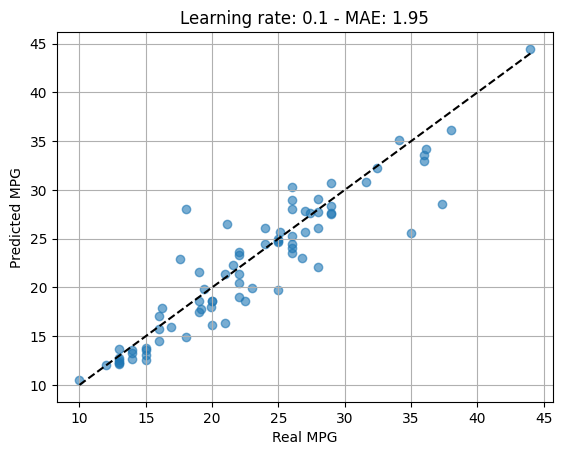

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 602.1313 - val_loss: 22.6831
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18.3456 - val_loss: 16.3214
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11.5845 - val_loss: 9.7327
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.2150 - val_loss: 7.1362
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.7529 - val_loss: 6.7645
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.9333 - val_loss: 6.7749
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.8221 - val_loss: 6.7767
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.6627 - val_loss: 7.0116
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.6442 - val_loss: 7.2566
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.6327 - val_loss: 7.3048
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.6306 - val_loss: 7.2633
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.6256 - val_loss: 7

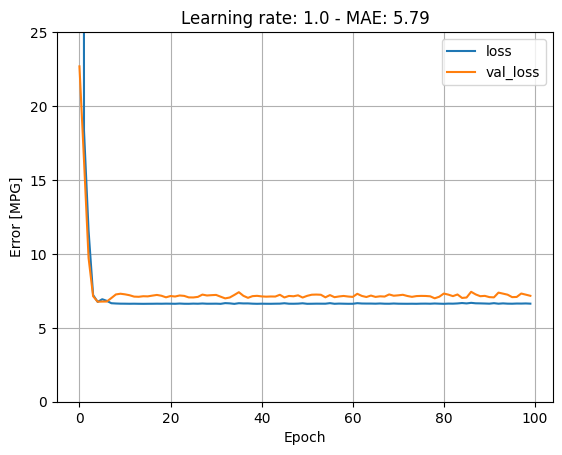

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


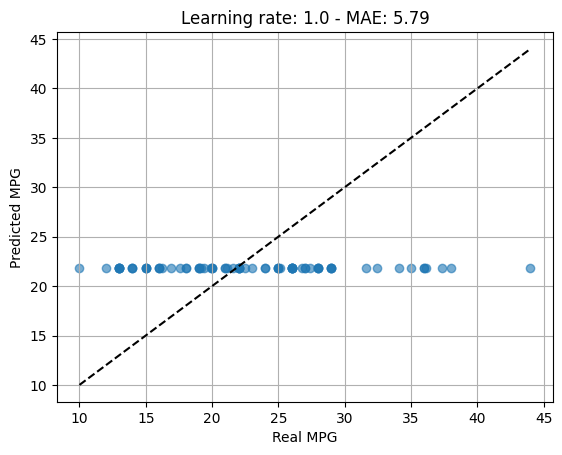

{0.01: 2.119541883468628, 0.1: 1.9467252492904663, 1.0: 5.793600559234619}


In [36]:
results = {}

for learning_rate in [0.01, 0.1, 1.0]: 
    dnn_model = build_deep_model(normalizer, lr=learning_rate)
    dnn_model.summary()
    history = dnn_model.fit(
        X_train, Y_train,
        epochs=100,
        verbose=1,
        validation_split=0.2
    )
    mae = dnn_model.evaluate(X_test, Y_test, verbose=1)
    results[learning_rate] = mae
    plot_loss(history, title=f"Learning rate: {learning_rate} - MAE: {mae:.2f}")
    
    y_pred = dnn_model.predict(X_test).flatten()
    plt.figure()
    plt.scatter(Y_test, y_pred, alpha=0.6)
    plt.plot([Y_test.min(), Y_test.max()],
             [Y_test.min(), Y_test.max()], color="k", linestyle="--")
    plt.xlabel("Real MPG")
    plt.ylabel("Predicted MPG")
    plt.title(f"Learning rate: {learning_rate} - MAE: {mae:.2f}")
    plt.grid(True)
    plt.show()

print(results)

## Analiza Wyników

## Podsumowanie oraz wnioski